This notebook generates images using the **StyleGAN2-ADA** (Adaptive Discriminator Augmentation) architecture. This generative model is optimized for training on limited datasets. By employing ADA, it prevents the model from overfitting, allowing for high-quality image synthesis.

Used datasets were DENTEX and TUFTS.

# IMPORTS
This section downloads the StyleGAN2-ADA repository from GitHub and imports datasets from Google Drive.

In [ ]:
import numpy as np 
import pandas as pd
import os

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1EOWr3VI-q03fw2e4wCUhAcr4iRxQ1fsA -O ./data/   # Image dataset download
!gdown --folder https://drive.google.com/drive/folders/1HKCXBZcltonnDdbjtDT6RQD9ZcrGBnyj -O ./data/   # StyleGAN2 trained weights

# Installing SyleGAN2-ADA repository
!pip install ninja
!pip install opensimplex

if not os.path.isdir("stylegan2-ada-pytorch"):
    !git clone https://github.com/dvschultz/stylegan2-ada-pytorch

# UTILS
This section includes patches and corrections for code compatibility with kaggle environment.

In [ ]:
# VERSION COMPATIBILITY PATCHES
import os

%cd stylegan2-ada-pytorch

# Enabling PyTorch functions. Disabling old NVIDIA methods.
!sed -i 's/enabled = True/enabled = False/g' torch_utils/ops/conv2d_gradfix.py
!sed -i 's/enabled = True/enabled = False/g' torch_utils/ops/grid_sample_gradfix.py

!sed -i 's/super().__init__(dataset)/super().__init__()/g' torch_utils/misc.py

# Disabling native C++ plugins (they don't work) and forcing PyTorch usage
files_to_patch = [
    'torch_utils/ops/bias_act.py',
    'torch_utils/ops/upfirdn2d.py'
]

for filename in files_to_patch:
    with open(filename, 'r') as f:
        code = f.read()

    if 'def _init():\n    return False' not in code:
        code = code.replace('def _init():', 'def _init():\n    return False\n')

    with open(filename, 'w') as f:
        f.write(code)

print("Patches applied!")

In [ ]:
# Training loop patch
import os

file_path = '/kaggle/working/stylegan2-ada-pytorch/training/training_loop.py'

if os.path.exists(file_path):
    with open(file_path, 'r') as file:
        file_data = file.read()

    file_data = file_data.replace(
        r"ignore_regex=r'.*\.w_avg'", 
        r"ignore_regex=r'.*\.(w_avg|noise_const|noise_strength)'"
    )

    with open(file_path, 'w') as file:
        file.write(file_data)
        
    print("training_loop.py successfully patched!")
else:
    print("File not found. Make sure your path to stylegan2-ada is correct.")

___________________
# DATA PRE-PROCESSING
To ensure consistency when integrating multiple datasets, the following preprocessing pipeline was implemented:
1. Border Cropping
2. Resizing to 256x256
3. CLAHE (Contrast Limited Adaptive Histogram Equalization)
5. Grayscale to RGB conversion for compatibility with the pretrained ADA model



In [ ]:
import os
import cv2
import numpy as np
import zipfile
from pathlib import Path

## Path Setup
%cd /kaggle/working/

BASE_DIR = Path('.').resolve()
DATA_DIR = BASE_DIR / 'data' / 'styleGAN2'
OUT_FOLDER = BASE_DIR / 'output_datasets' / 'ALL_RGB_256Q'

OUT_FOLDER.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

## ZIP Decompression
zip_paths = {
    "TUFTS": DATA_DIR / 'Radiographs.zip',
    "DENTEX_QE": DATA_DIR / 'DENTEX_QE_TRAIN_ONLY.zip',
    "DENTEX_Q": DATA_DIR / 'quadrant_xrays.zip',
    "DENTEX_UN": DATA_DIR / 'unlabeled_xrays.zip',
    "DENTEX_VAL": DATA_DIR / 'validation_xrays.zip',
    "DENTEX_QED": DATA_DIR / 'DENTEX_QED_TRAIN_ONLY.zip'
}

print("Starting ZIP decompression...")
for name, path_zip in zip_paths.items():
    if path_zip.exists():
        extract_dir = DATA_DIR / name
        print(f"Extracting {name} in {extract_dir}...")
        
        with zipfile.ZipFile(path_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)            
        path_zip.unlink()
        
    else:
        print(f"WARNING: zip file not found at {path_zip}")


## READING FOLDERS' DATA
dataset_folders = {name: DATA_DIR / name for name in zip_paths.keys()}

valid_extensions = {'.jpg', '.jpeg', '.png', '.tif', '.bmp'}
all_image_paths = []

for name, folder_path in dataset_folders.items():
    if folder_path.exists() and folder_path.is_dir():
        for file_path in folder_path.rglob('*'):
            if file_path.suffix.lower() in valid_extensions:
                all_image_paths.append(file_path)
    else:
        print(f"WARNING: Folder not found -> {folder_path}")

print(f"{len(all_image_paths)} images found")


## Pre-PROCESSING LOOP
img_counter = 1  
img_res = 256

print("\nStarting image processing...")
for path_input in all_image_paths:
    nome_file_png = f"{img_counter:04d}.png"  # Generating sequential file name (es. 0001.png)
    path_output = OUT_FOLDER / nome_file_png

    img_array = np.fromfile(str(path_input), np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    if img is not None:
        h, w = img.shape[:2]
        
        # 1. SQUARED CROP
        margin_h = int(h * 0.022)
        sq_edge = h - (2 * margin_h)   # computing the square edge

        margin_w = int((w - sq_edge) / 2)

        img_cropped = img[margin_h : margin_h + sq_edge, margin_w : margin_w + sq_edge] # Slicing

        # 2. RESIZING at img_res
        new_h = img_res
        new_w = img_res
        
        img_resized = cv2.resize(img_cropped, (new_w, new_h), interpolation=cv2.INTER_AREA) # Interpolation to reduce artifacts

        # 3. CLAHE
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8,8))
        img_normalized = clahe.apply(gray)

        # 4. RGB conversion (necessary for StyleGAN2)
        img_final_bgr = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2BGR)

        # 5. Saving
        _, buffer = cv2.imencode('.png', img_final_bgr)
        buffer.tofile(str(path_output))

        img_counter += 1
    else:
        print(f"Error while loading: {path_input}")

print(f"\nData Processing complete")

______________
# TRAINING

In [ ]:
!mkdir -p ./datasets

!python ./stylegan2-ada-pytorch/dataset_tool.py \
    --source=./output_datasets/ALL_RGB_256Q \
    --dest=./datasets/orto_dataset \
    --width=256 \
    --height=256

In [ ]:
!python ./stylegan2-ada-pytorch/train.py \
    --outdir=./results \
    --data=./datasets/orto_dataset\
    --gpus=2 \
    --batch=32 \
    --gamma=0.8192 \
    --mirror=1 \
    --resume=./data/WEIGHTS/styleGAN2_FID32weights.pkl \
    --snap=5 \
    --kimg=3000

# RESULTS

In [ ]:
import os
SNAPSHOT_PKL = '/kaggle/working/data/WEIGHTS/styleGAN2_FID32weights.pkl'

os.makedirs('/kaggle/working/stylegan_256_gen', exist_ok=True)

%cd /kaggle/working/stylegan2-ada-pytorch
!python generate.py \
    --network={SNAPSHOT_PKL} \
    --seeds=1-250 \
    --trunc=0.7 \
    --outdir=/kaggle/working/stylegan_256_gen

print(f"\n250 synthetic images generated in /kaggle/working/stylegan_256_gen")

# Examples
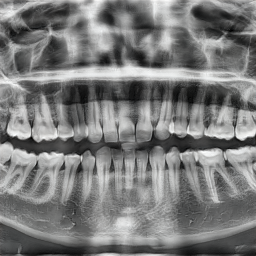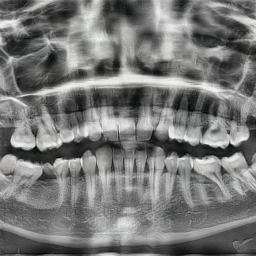
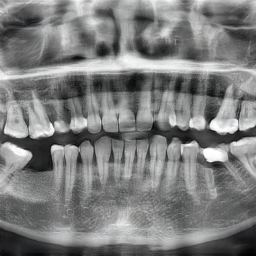
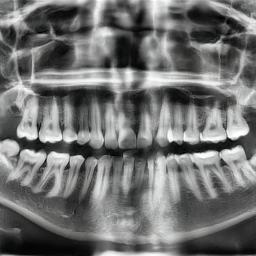